In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import cv2
import matplotlib.pyplot as plt

from os import listdir
import os
import time

In [5]:
data_gen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

print("Augmentation generator created!")

Augmentation generator created!


In [6]:
train_dir = "../dataset/split/train"
augmented_dir = "../dataset/augmented"

In [7]:
classes = ["glioma", "meningioma", "pituitary"]

for class_name in classes:
    os.makedirs(
        os.path.join(augmented_dir, class_name),
        exist_ok=True
    )

In [8]:
for class_name in classes:
    class_path = os.path.join(train_dir, class_name)
    
    files = os.listdir(class_path)
    
    print(class_name, ":", len(files), "images")

glioma : 1140 images
meningioma : 566 images
pituitary : 744 images


In [9]:
class_name = "glioma"

class_path = os.path.join(train_dir, class_name)

filename = os.listdir(class_path)[0]

image_path = os.path.join(class_path, filename)

image = cv2.imread(image_path)

print("Image:", filename)
print("Shape:", image.shape)

Image: 1841.png
Shape: (352, 406, 3)


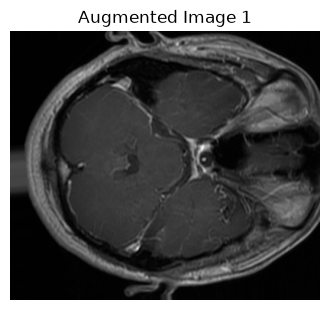

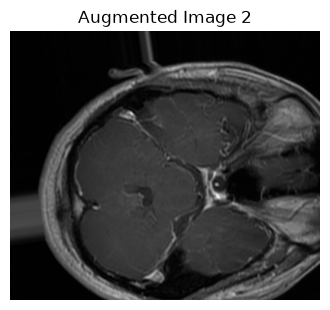

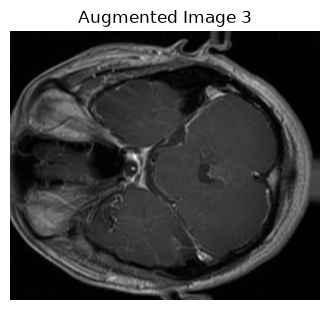

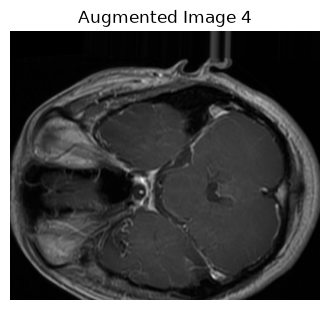

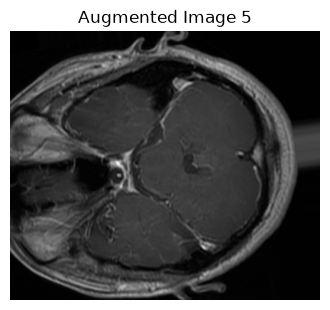

In [10]:
image = image.reshape((1,) + image.shape)

generated = data_gen.flow(
    image,
    batch_size=1
)

for i in range(5):
    augmented_image = next(generated)[0].astype("uint8")

    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(augmented_image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Augmented Image {i + 1}")
    plt.show()

In [12]:
import cv2
import os
from os import listdir

def augment_data(file_dir, n_generated_samples, save_to_dir):

    for filename in listdir(file_dir):

        # Read image
        image = cv2.imread(os.path.join(file_dir, filename))

        # Add batch dimension
        image = image.reshape((1,) + image.shape)

        # Prefix for generated filenames
        save_prefix = "aug_" + filename[:-4]

        i = 0

        # Generate augmented images
        for batch in data_gen.flow(
            image,
            batch_size=1,
            save_to_dir=save_to_dir,
            save_prefix=save_prefix,
            save_format="png"
        ):
            i += 1

            if i > n_generated_samples:
                break

In [13]:
augment_data(
    "../dataset/split/train/glioma",
    2,
    "../dataset/augmented/glioma"
)

In [17]:
glioma_aug_dir = "../dataset/augmented/glioma"

glioma_files = os.listdir(glioma_aug_dir)

print("Augmented Glioma images:", len(glioma_files))

Augmented Glioma images: 3420


In [18]:
augment_data(
    "../dataset/split/train/meningioma",
    5,
    "../dataset/augmented/meningioma"
)

print("Meningioma augmentation completed.")

Meningioma augmentation completed.


In [19]:
meningioma_aug_dir = "../dataset/augmented/meningioma"

meningioma_files = os.listdir(meningioma_aug_dir)

print("Augmented Meningioma images:", len(meningioma_files))

Augmented Meningioma images: 3395


In [20]:
augment_data(
    "../dataset/split/train/pituitary",
    4,
    "../dataset/augmented/pituitary"
)

print("Pituitary augmentation completed.")

Pituitary augmentation completed.


In [23]:
pituitary_aug_dir = "../dataset/augmented/pituitary"

pituitary_files = os.listdir(pituitary_aug_dir)

print("Augmented Pituitary images:", len(pituitary_files))

Augmented Pituitary images: 3719


In [24]:
import os

classes = ["glioma", "meningioma", "pituitary"]

total = 0

for class_name in classes:
    class_dir = os.path.join("../dataset/augmented", class_name)
    count = len(os.listdir(class_dir))
    
    print(f"{class_name.capitalize()}: {count}")
    total += count

print("--------------------")
print("Total augmented images:", total)

Glioma: 3420
Meningioma: 3395
Pituitary: 3719
--------------------
Total augmented images: 10534
